# Ex.No.9 - Boosting Algorithms

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 31/03/2026_

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load Dataset
df = pd.read_csv(r"D:\VI\FOML\Datasets\house_price_regression_dataset.csv")
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
# Features and Target
X = df.drop("House_Price", axis=1)
y = df["House_Price"]

In [4]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (800, 7)
Test Shape  : (200, 7)


In [5]:
# Define Models
models = {
    "Without Boosting": DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        objective="reg:squarederror",
        random_state=42
    )
}

In [6]:
# Train Models and Store Results
results = {}
predictions = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results[name] = {
        "Train R2 Accuracy": train_r2 * 100,
        "Test R2 Accuracy": test_r2 * 100,
        "Train RMSE value": train_rmse,
        "Test RMSE value": test_rmse
    }

    predictions[name] = test_pred

In [7]:
# Results Table
res = pd.DataFrame(results).T
res

,Train R2 Accuracy,Test R2 Accuracy,Train RMSE value,Test RMSE value
Without Boosting,99.780832,98.533381,11859.678832,30746.797860
AdaBoost,98.666319,98.460074,29255.701036,31505.846845
Gradient Boosting,99.878317,99.650994,8836.903578,14998.853218
XGBoost,99.956429,99.660288,5287.930173,14797.786474


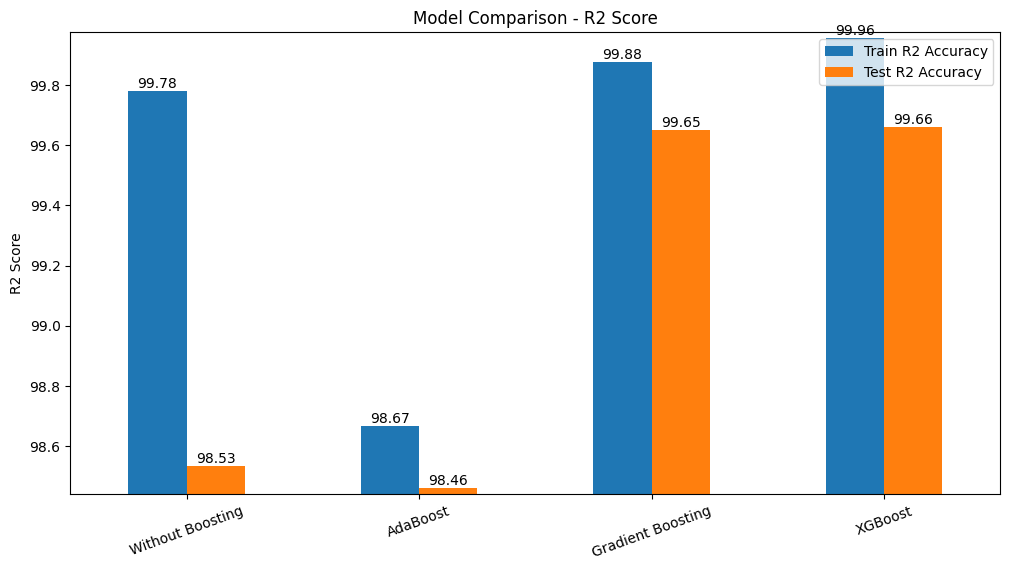

In [8]:
# Comparison Graph

ax = res[["Train R2 Accuracy", "Test R2 Accuracy"]].plot(kind="bar", figsize=(12,6))

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
    
plt.title("Model Comparison - R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)

plt.ylim(res[["Train R2 Accuracy", "Test R2 Accuracy"]].min().min() - 0.02,
         res[["Train R2 Accuracy", "Test R2 Accuracy"]].max().max() + 0.02)

plt.show()

In [9]:
# Best Model
best_model = res["Test R2 Accuracy"].idxmax()
print("Best Model :", best_model)

Best Model : XGBoost


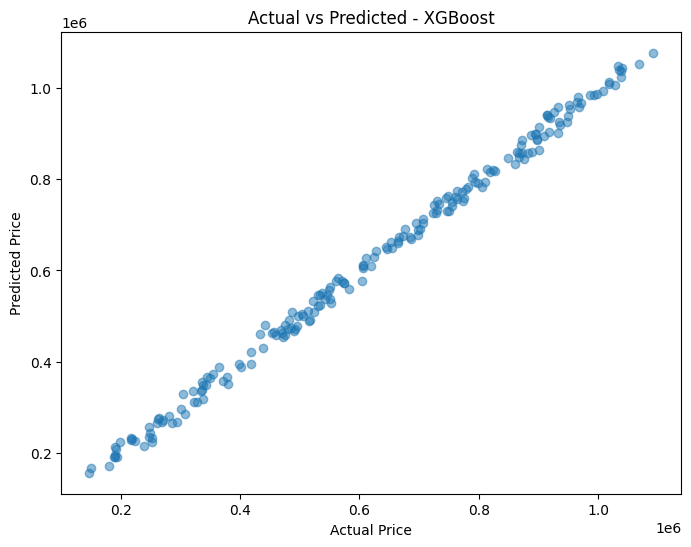

In [10]:
# Actual vs Predicted Graph (Best Model)
best_pred = predictions[best_model]

plt.figure(figsize=(8,6))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted - " + best_model)
plt.show()

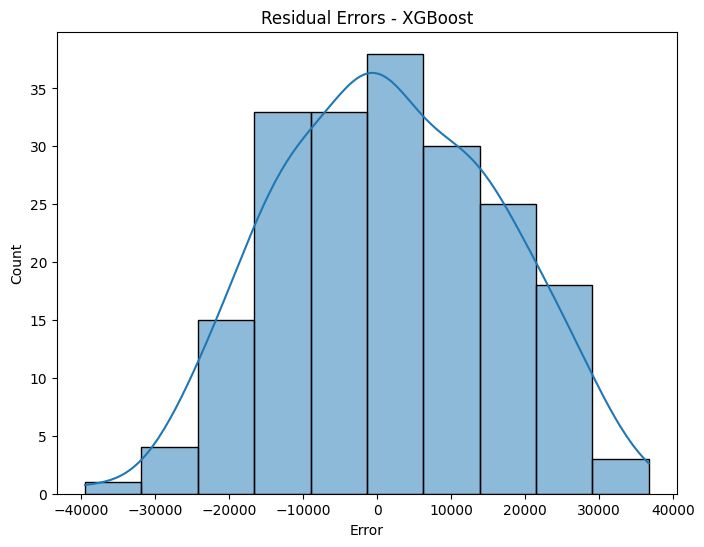

In [11]:
# Residual Error Plot
errors = y_test - best_pred

plt.figure(figsize=(8,6))
sns.histplot(errors, kde=True)
plt.title("Residual Errors - " + best_model)
plt.xlabel("Error")
plt.show()

In [12]:
# Custom Input Prediction Using Correct Column Names

custom_data = pd.DataFrame([{
    "Square_Footage": 2500,
    "Num_Bedrooms": 4,
    "Num_Bathrooms": 3,
    "Year_Built": 2015,
    "Lot_Size": 5000,
    "Garage_Size": 2,
    "Neighborhood_Quality": 8
}])


# Predict using all 4 models
for name, model in models.items():
    
    model.fit(X_train, y_train)
    pred = model.predict(custom_data)
    
    print(name)
    print("Predicted House Price :", round(pred[0],2))
    print()

Without Boosting
Predicted House Price : 589007.05

AdaBoost
Predicted House Price : 567971.49

Gradient Boosting
Predicted House Price : 626716.77

XGBoost
Predicted House Price : 635443.7

